In [2]:
# Importamos librerías básicas
import pandas as pd
import numpy as np
import re
from google.colab import files
import io
# Para segmentar oraciones
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [18]:
# Sube el archivo de Excel desde tu computadora
uploaded = files.upload()

# Asume que solo se sube un archivo y obtiene el nombre del archivo
for filename in uploaded.keys():
    print(f'Archivo subido: {filename}')
    # Lee el archivo de Excel en un DataFrame de pandas
    df = pd.read_excel(io.BytesIO(uploaded[filename]))

# Muestra las primeras 5 filas del DataFrame
print("Primeras 5 filas del DataFrame:")
display(df.head())

Saving 00_base.xlsx to 00_base (1).xlsx
Archivo subido: 00_base (1).xlsx
Primeras 5 filas del DataFrame:


,Law,Article,Spanish text,Relevance,Interpretability,Completeness,Differential Regime,Discretionality,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,Ley 105 de 1958,22,Todas las mercancías o materias primas que ent...,1,3,1,1,1,7,NaN,NaN,NaN
1,Ley 105 de 1958,27,Cuando se introduzcan al país artículos elabor...,1,3,1,1,1,7,NaN,NaN,NaN
2,Ley 47 de 1981,28,De la reexpedición de mercancías. La reexpedic...,1,3,1,1,1,7,NaN,NaN,NaN
3,Ley 47 de 1981,37,De los gravámenes aplicables a insumos y mater...,1,3,1,1,1,7,NaN,NaN,NaN
4,Ley 109 de 1985,34,DE LAS ZONAS FRANCAS DE CARACTER TRANSITORIO. ...,1,3,1,1,1,7,NaN,NaN,NaN


In [19]:
# Nos aseguramos de que el texto sea string
df["Spanish text"] = df["Spanish text"].astype(str)

# Creamos una versión limpia (sin saltos de línea raros)
df["text_clean"] = df["Spanish text"].str.replace("\n", " ")


In [20]:
# Contamos palabras por artículo
df["n_words"] = df["text_clean"].apply(
    lambda x: len(x.split())
)


In [21]:
# Contamos oraciones usando NLTK
# Descarga el recurso 'punkt_tab' necesario para la tokenización.
# Aunque lo ideal es descargarlo una vez al inicio del notebook,
# lo incluimos aquí para que la celda funcione de forma independiente,
# siguiendo las instrucciones del error.
nltk.download('punkt_tab')

df["n_sentences"] = df["text_clean"].apply(
    lambda x: len(sent_tokenize(x))
)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [22]:
# Evitamos división por cero
df["avg_sentence_length"] = df["n_words"] / df["n_sentences"].replace(0, np.nan)


In [23]:
# Definimos patrones de referencia normativa
reference_patterns = [
    r"artículo\s+\d+",
    r"art\.\s*\d+",
    r"ley\s+\d+",
    r"decreto\s+\d+",
    r"numeral\s+\d+",
    r"parágrafo",
    r"inciso"
]

# Función para contar referencias
def count_references(text):
    count = 0
    for pattern in reference_patterns:
        count += len(re.findall(pattern, text.lower()))
    return count

# Aplicamos la función
df["n_references"] = df["text_clean"].apply(count_references)


In [24]:
# Normalizamos cada métrica entre 0 y 1
for col in ["n_words", "avg_sentence_length", "n_references"]:
    df[col + "_norm"] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())


In [25]:
# Índice agregado de complejidad (promedio simple)
df["legal_complexity_index"] = (
    df["n_words_norm"] +
    df["avg_sentence_length_norm"] +
    df["n_references_norm"]
) / 3


In [26]:
# Seleccionamos columnas relevantes para análisis
df_result = df[
    ["Law", "Article", "n_words", "n_sentences",
     "avg_sentence_length", "n_references",
     "legal_complexity_index"]
]

df_result.head()


,Law,Article,n_words,n_sentences,avg_sentence_length,n_references,legal_complexity_index
0,Ley 105 de 1958,22,87,1,87.000000,0,0.186815
1,Ley 105 de 1958,27,68,2,34.000000,0,0.095375
2,Ley 47 de 1981,28,53,3,17.666667,0,0.058912
3,Ley 47 de 1981,37,146,4,36.500000,0,0.169529
4,Ley 109 de 1985,34,83,2,41.500000,0,0.119466


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")



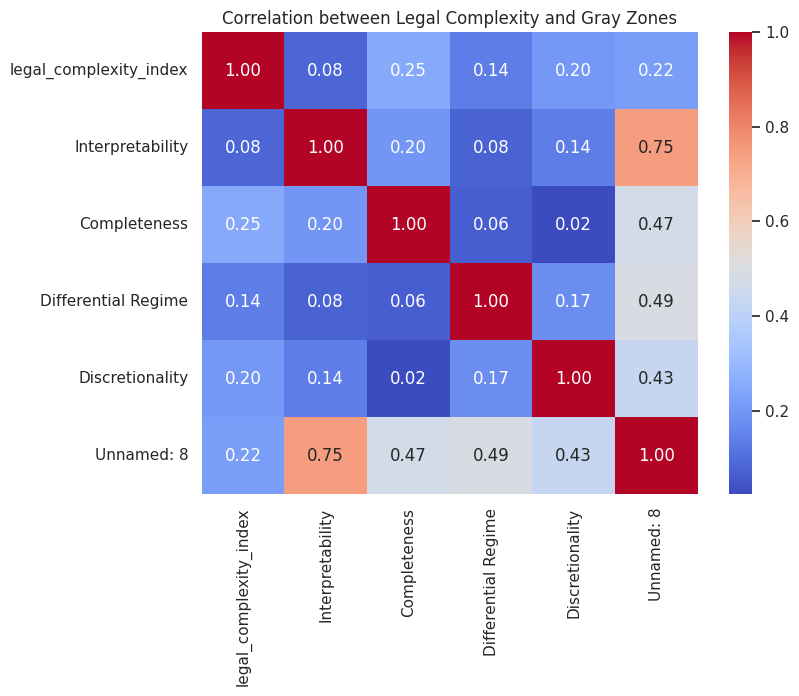

In [30]:
# Seleccionamos variables relevantes
cols = [
    "legal_complexity_index",
    "Interpretability",
    "Completeness",
    "Differential Regime",
    "Discretionality",
    "Unnamed: 8"
]

corr = df[cols].corr()

# Graficamos
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Legal Complexity and Gray Zones")
plt.show()


In [31]:
df["complexity_group"] = pd.qcut(
    df["legal_complexity_index"],
    q=3,
    labels=["Low complexity", "Medium complexity", "High complexity"]
)


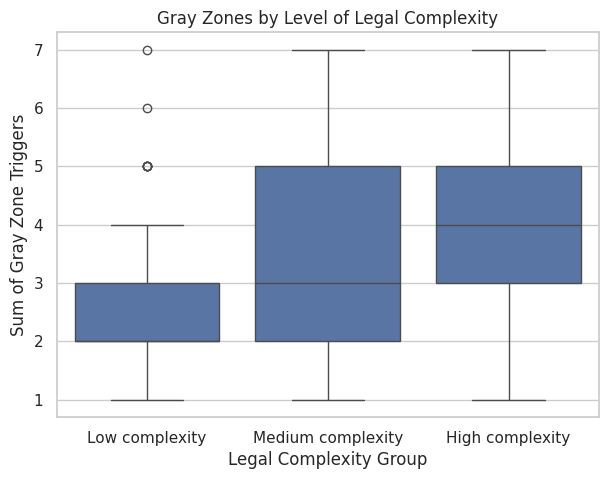

In [33]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x="complexity_group",
    y="Unnamed: 8",
    data=df
)
plt.title("Gray Zones by Level of Legal Complexity")
plt.xlabel("Legal Complexity Group")
plt.ylabel("Sum of Gray Zone Triggers")
plt.show()


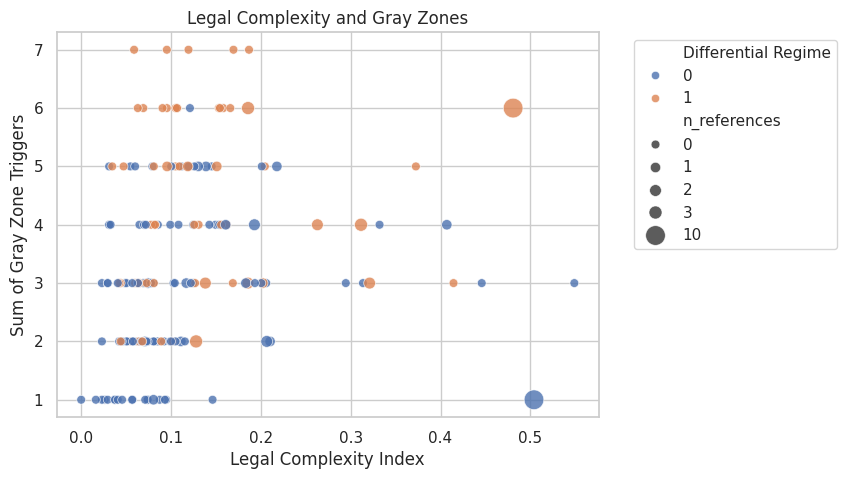

In [46]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="legal_complexity_index",
    y="Unnamed: 8",
    hue="Differential Regime",
    size="n_references",
    sizes=(40, 200),
    data=df,
    alpha=0.8
)

plt.title("Legal Complexity and Gray Zones")
plt.xlabel("Legal Complexity Index")
plt.ylabel("Sum of Gray Zone Triggers")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()


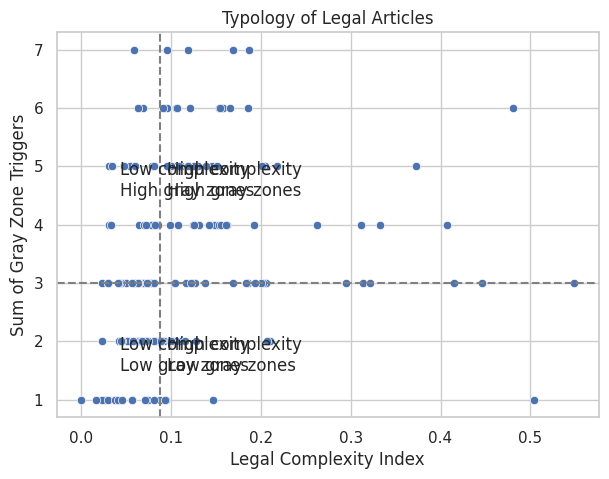

In [39]:
# Umbrales (medianas)
x_thr = df["legal_complexity_index"].median()
y_thr = df["Unnamed: 8"].median()

plt.figure(figsize=(7,5))
sns.scatterplot(
    x="legal_complexity_index",
    y="Unnamed: 8",
    data=df
)

# Líneas de corte
plt.axvline(x=x_thr, linestyle="--", color="gray")
plt.axhline(y=y_thr, linestyle="--", color="gray")

plt.text(x_thr*0.5, y_thr*1.5, "Low complexity\nHigh gray zones")
plt.text(x_thr*1.1, y_thr*1.5, "High complexity\nHigh gray zones")
plt.text(x_thr*0.5, y_thr*0.5, "Low complexity\nLow gray zones")
plt.text(x_thr*1.1, y_thr*0.5, "High complexity\nLow gray zones")

plt.title("Typology of Legal Articles")
plt.xlabel("Legal Complexity Index")
plt.ylabel("Sum of Gray Zone Triggers")
plt.show()


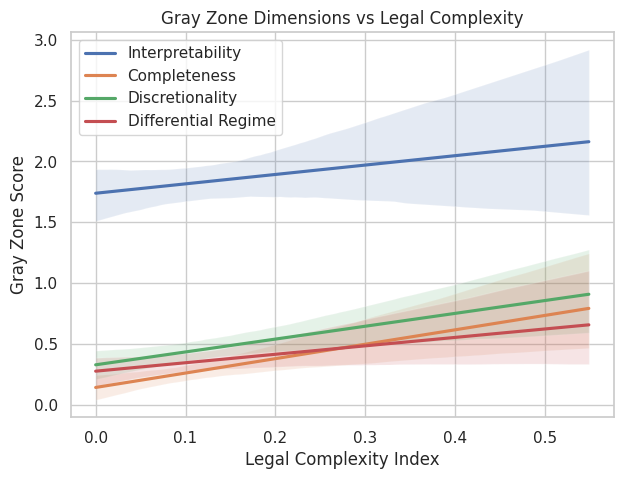

In [41]:
plt.figure(figsize=(7,5))

for col in ["Interpretability", "Completeness", "Discretionality","Differential Regime"]:
    sns.regplot(
        x="legal_complexity_index",
        y=col,
        data=df,
        scatter=False,
        label=col
    )

plt.legend()
plt.title("Gray Zone Dimensions vs Legal Complexity")
plt.xlabel("Legal Complexity Index")
plt.ylabel("Gray Zone Score")
plt.show()


In [44]:
df_rank = df.sort_values(
    by=["legal_complexity_index", "Unnamed: 8"],
    ascending=False
)[["Law", "Article", "legal_complexity_index", "Unnamed: 8"]]

df_rank.head(10)


,Law,Article,legal_complexity_index,Unnamed: 8
72,Ley 105 de 1958,9,0.548913,3
168,Ley 1004 de 2005,13,0.504004,1
17,Ley 1004 de 2005,10,0.480779,6
82,Ley 47 de 1981,11,0.445835,3
88,Ley 47 de 1981,46,0.414436,3
45,Ley 105 de 1958,21,0.406963,4
27,Ley 47 de 1981,22,0.372549,5
44,Ley 105 de 1958,17,0.332115,4
91,Ley 47 de 1981,52,0.321043,3
81,Ley 47 de 1981,10,0.313665,3
